In [14]:
import torch
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import random
import copy
import time

In [3]:
train_transform = transforms.Compose([transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(
            [0.490, 0.449, 0.411],
            [0.231, 0.221, 0.230])])

val_transform = transforms.Compose([transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(
            [0.490, 0.449, 0.411],
            [0.231, 0.221, 0.230])])

train_dataset = datasets.ImageFolder(root='../data/hymenoptera_data/train', transform=train_transform)
val_dataset = datasets.ImageFolder(root='../data/hymenoptera_data/val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [25]:
classes = train_dataset.classes
classes

['ants', 'bees']

In [5]:
next(iter(train_loader))[0].shape

torch.Size([8, 3, 224, 224])

In [6]:
images, labels = next(iter(train_loader))

images.shape, labels.shape

(torch.Size([8, 3, 224, 224]), torch.Size([8]))

In [7]:
def imshow(tensor:torch.Tensor, title=None):
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    
    # Denormalize
    mean = torch.tensor([0.490, 0.449, 0.411])
    std = torch.tensor([0.231, 0.221, 0.230])
    image = image * std[:, None, None] + mean[:, None, None]
    image = torch.clamp(image, 0, 1)
    
    image = image.numpy().transpose((1, 2, 0))
    
    plt.imshow(image)
    plt.axis("off")
    if title is not None:
        plt.title(title)

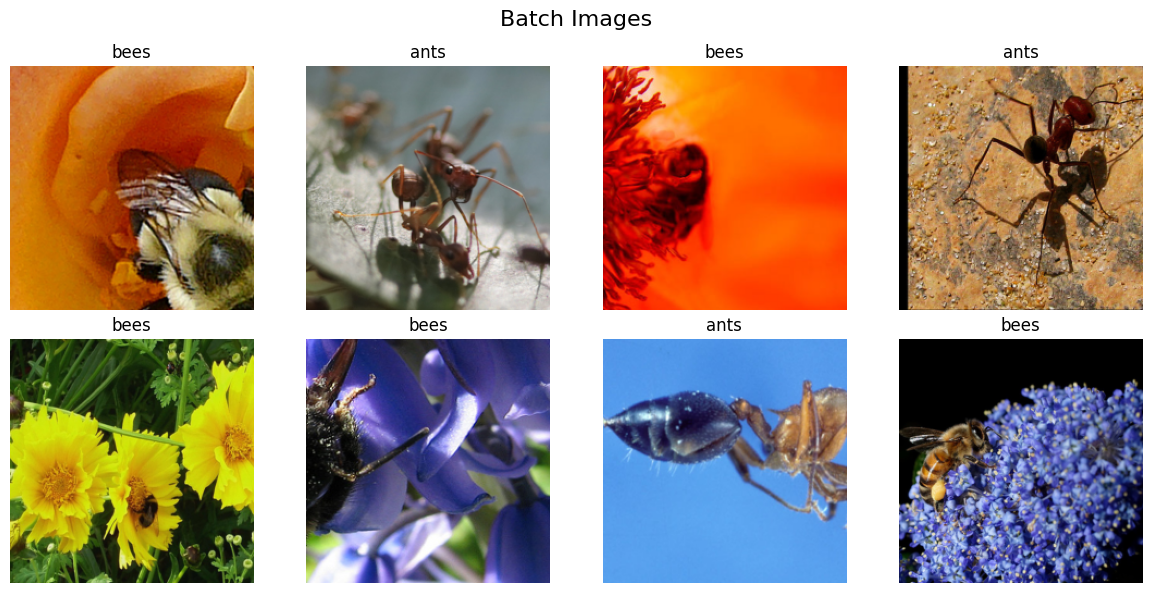

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Batch Images", fontsize=16)

for idx in range(8):
    row = idx // 4
    col = idx % 4
    
    plt.subplot(2, 4, idx + 1)
    imshow(images[idx], title=train_dataset.classes[labels[idx]])

plt.tight_layout()
plt.show()

In [9]:
model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [10]:
model.classifier[6] = torch.nn.Linear(in_features=4096, out_features=len(train_dataset.classes))
model.classifier

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)

In [ ]:
def finetune_model(model, train_loader, val_loader, loss_fn, optimizer, num_epochs=10, device='cpu'):
    start_time = time.time()
    model = model.to(device)

    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("=" * 30)

        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = loss_fn(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}\n")

        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

    elapsed = time.time() - start_time
    print(f"Training complete in {elapsed//60:.0f}m {elapsed%60:.0f}s")
    print(f"Best Validation Accuracy: {best_acc:.4f}")

    model.load_state_dict(best_weights)
    return model


In [23]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

In [24]:
model_finetuned = finetune_model(
    model, 
    train_loader,
    val_loader,
    loss_fn,
    optimizer)

Epoch 1/10
Train Loss: 0.4993, Train Acc: 0.7787
Val   Loss: 0.3095, Val   Acc: 0.8758

Epoch 2/10
Train Loss: 0.2957, Train Acc: 0.8811
Val   Loss: 0.2657, Val   Acc: 0.9085

Epoch 3/10
Train Loss: 0.2426, Train Acc: 0.8934
Val   Loss: 0.2607, Val   Acc: 0.9020

Epoch 4/10
Train Loss: 0.2148, Train Acc: 0.9139
Val   Loss: 0.2688, Val   Acc: 0.9150

Epoch 5/10
Train Loss: 0.1993, Train Acc: 0.9262
Val   Loss: 0.2651, Val   Acc: 0.9085

Epoch 6/10
Train Loss: 0.2143, Train Acc: 0.9221
Val   Loss: 0.2733, Val   Acc: 0.9216

Epoch 7/10
Train Loss: 0.1777, Train Acc: 0.9303
Val   Loss: 0.2675, Val   Acc: 0.9216

Epoch 8/10
Train Loss: 0.1361, Train Acc: 0.9631
Val   Loss: 0.2754, Val   Acc: 0.9150

Epoch 9/10
Train Loss: 0.1722, Train Acc: 0.9508
Val   Loss: 0.2801, Val   Acc: 0.9020

Epoch 10/10
Train Loss: 0.1315, Train Acc: 0.9426
Val   Loss: 0.2744, Val   Acc: 0.9150

Training complete in 2m 13s
Best Validation Accuracy: 0.9216


In [33]:
def visualize_predictions(
    model, 
    dataset, 
    classes, 
    device="cpu", 
    max_num_imgs=4, 
):
    was_training = model.training
    model.eval()

    plt.figure(figsize=(12, 8))
    shown = 0

    with torch.no_grad():
        indices = random.sample(range(len(dataset)), max_num_imgs)
        samples = [dataset[i] for i in indices] 

        for i, (img, tgt) in enumerate(samples):
            img_input = img.unsqueeze(0).to(device)
            output = model(img_input)
            _, pred = torch.max(output, 1)

            ax = plt.subplot(max_num_imgs // 4, 4, i + 1)
            ax.axis("off")
            ax.set_title(f"Pred: {classes[pred.item()]}\nTarget: {classes[tgt]}")
            imshow(img)
            shown += 1
                
    model.train(mode=was_training)


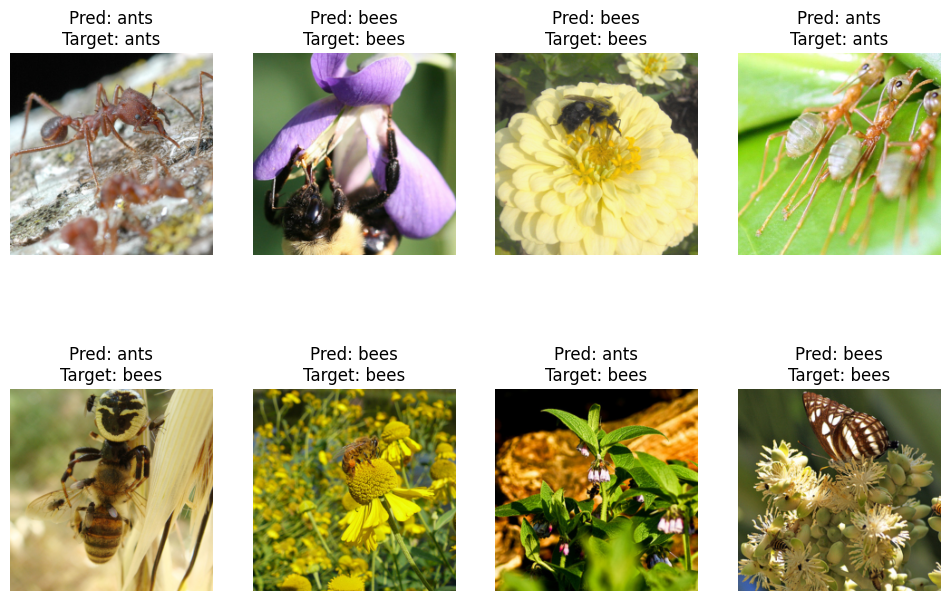

In [34]:
visualize_predictions(
    model_finetuned,
    val_dataset,
    classes,
    device="cpu",
    max_num_imgs=8,
)

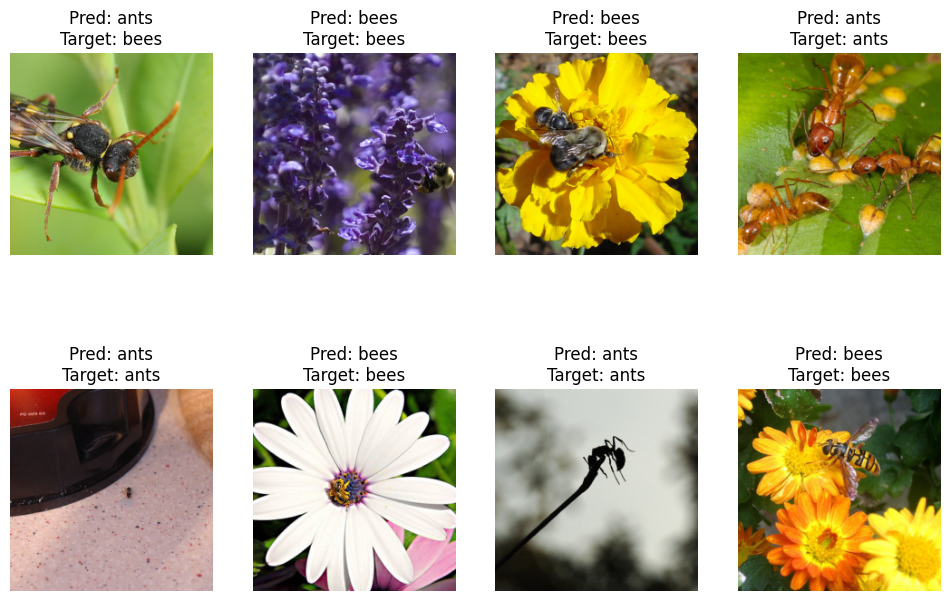

In [35]:
visualize_predictions(
    model,
    val_dataset,
    classes,
    device="cpu",
    max_num_imgs=8,
)